# The Bowman-2018 pipeline: single-day analysis

This notebook performs the single-day parts of the analysis pipeline using the python `edges-collab` stack. This loads in a full day of data, flags out bad integrations, flags RFI, and averages all retained LSTs.

In [29]:
data_dir: str = '/data5/edges/data/EDGES3_data/MRO/mro/ant/2023/'
#alan_output_dir: str = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/"
cachedir: str = "./cache"
outputsdir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days/prefect-outputs/"

year: int = 2023
day: int = 305

do_aux_filter: bool = True
aux_filter_params: dict = {
    'minima': {},
    'maxima': {
        'adcmax': 0.4
    }
}

lst_min: float = 0
lst_max: float = 24


do_power_percent_filter: bool = True
power_percent_params = {
    'min_threshold': 3,
    'max_threshold': 10
}

do_peak_orbcomm_filter: bool = True
peak_orbcomm_params = {
    'threshold': 40.0
}

do_maxfm_filter: bool = True
maxfm_filter_params = {
    'threshold': 2000.0
}

do_rmsf_filter: bool = True
rmsf_filter_params = {
    'freq_range': [60., 80.],
    'threshold': 200.0
}

lstbin_params = {    
    "binsize": 0.5,
    'first_edge': 6.25,
    'max_edge': 6.25,
    'use_model_residuals': False,
    'in_gha': True,
}

gauss_smooth_params = {
    "size": 8,
    'decimate_at': 0,
    'maintain_flags': 1,
    'flag_threshold': 0.25,
    'use_nsamples': True,
}

do_antenna_loss: bool = False
do_ground_loss: bool = False
do_beam_correction: bool = False  # should be True to match B18      

first_freqcut_min: float = 40.0  # MHz
first_freqcut_max: float = 100.0  # MHz

#inject_flags: bool = True
calfile: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days/specal.txt"


## Imports and Versions

In [2]:
from pathlib import Path
from importlib.metadata import version
from copy import deepcopy
import sys 

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
import pandas as pd
from pygsdata import plots, GSData, GSFlag
from pygsdata.select import select_freqs, select_lsts, lst_selector

from read_acq.gsdata import read_acq_to_gsdata, fast_lst_setter

from edges_cal import Calibrator
from edges_cal.alanmode import read_specal_as_calibrator, read_spec_txt
from edges_cal import modelling as mdl
from edges_cal.tools import dicke_calibration

from edges_analysis.calibration.calibrate import approximate_temperature
from edges_analysis.const import KNOWN_TELESCOPES
from edges_analysis.averaging.freqbin import gauss_smooth
from edges_analysis.averaging.lstbin import lst_bin
from edges_analysis.filters import filters
from edges_pipelines import utils


In [3]:
utils.print_versions()

Versions: 
            read_acq: 1.1.1.dev6+gb1a6b4d
            pygsdata: 0.2.2.dev6+ge6726b0
           edges-cal: 7.1.0
            edges-io: 4.1.9.dev5+g08d3eed
      edges-analysis: 6.0.3.dev96+gf2b3739


## Load Data

In [4]:
cache = Path(cachedir)
cache.mkdir(exist_ok=True, parents=True)

In [7]:
#alan_output_dir = Path(alan_output_dir) / str(utils.yday_to_alanday(year, day))

In [17]:
obsname = f"{year}_{day:>03}"

In [26]:
files_to_load = sorted(Path(data_dir).glob(f"{year}_{day:03}_*.acq"))
data = read_acq_to_gsdata(files_to_load, telescope=KNOWN_TELESCOPES['edges3'], name=obsname, lst_setter=fast_lst_setter)

Reading 2023_305_00_00_14_ant.acq: 686lines [00:00, 883.77lines/s]
Reading 2023_305_01_30_03_ant.acq: 1349lines [00:01, 910.22lines/s]
Reading 2023_305_06_18_47_ant.acq: 1349lines [00:01, 883.74lines/s]
Reading 2023_305_09_15_08_ant.acq: 1349lines [00:01, 804.33lines/s]
Reading 2023_305_12_11_30_ant.acq: 1349lines [00:01, 786.52lines/s]
Reading 2023_305_15_07_50_ant.acq: 1349lines [00:01, 893.06lines/s]
Reading 2023_305_18_04_11_ant.acq: 1349lines [00:01, 926.52lines/s]
Reading 2023_305_21_00_32_ant.acq: 1349lines [00:01, 847.80lines/s]
Reading 2023_305_23_56_54_ant.acq: 23lines [00:00, 1012.40lines/s]


In [27]:
print(f"Number of integrations in the data: {data.ntimes}")

Number of integrations in the data: 3387


In [28]:
if calfile.endswith(".txt"):
    calobs = read_specal_as_calibrator(calfile, t_load=300, t_load_ns=1000)
else:
    calobs = Calibrator.from_calfile(calfile)

## Multi-Integration Data Workflow

### Select LSTs

In [30]:
mask = lst_selector(data.lsts, data.loads, load='all', lst_range=[lst_min, lst_max], gha=True)

In [15]:
#alan_gha_mask = time_flags_alan['gha0'].astype(bool) & time_flags_alan['gha1'].astype(bool) & time_flags_alan['gha2'].astype(bool)

In [16]:
# Check that our selected LSTs exactly match Alan's
#assert np.sum(alan_gha_mask ^ mask) == 0

In [31]:
data = select_lsts(data, lst_range=[lst_min, lst_max], gha=True, load='all')  # need to re-implement use_alan_coordinates...

In [18]:
# if data.ntimes == 0:
#     print("There are no LSTs in the range on this day! Exiting")
#     if np.any(alan_gha_mask):
#         raise AssertionError("THe C-code picked up some LSTs, but this notebook didn't!")
#     else:
#         sys.exit(0)

In [32]:
print(data.lsts.min(), data.lsts.max())

0h00m05.10220545s 23h59m42.03923356s


In [33]:
print(f"New minimum and maximum GHA: {data.gha.min()} -- {data.gha.max()}")

New minimum and maximum GHA: 0.005727661184977251 hourangle -- 23.99904274178047 hourangle


In [34]:
print(f"New number of integrations: {data.ntimes}")

New number of integrations: 3387


### Flag out bad integrations

In [35]:
if do_aux_filter:
    data = filters.aux_filter(data, **aux_filter_params)

In [36]:
if do_power_percent_filter:
    data = filters.power_percent_filter(data, **power_percent_params)

### Dicke-Switch Calibration and Approximating Temperature

In [37]:
data = dicke_calibration(data)

In [38]:
data = approximate_temperature(data, tload=calobs.t_load, tns=calobs.t_load_ns)

### More Integration Filters

In [39]:
if do_peak_orbcomm_filter:
    data = filters.peak_orbcomm_filter(data, **peak_orbcomm_params)

In [40]:
if do_maxfm_filter:
    data = filters.maxfm_filter(data, **maxfm_filter_params)

In [41]:
if do_rmsf_filter:
    data = filters.rmsf_filter(data, **rmsf_filter_params)

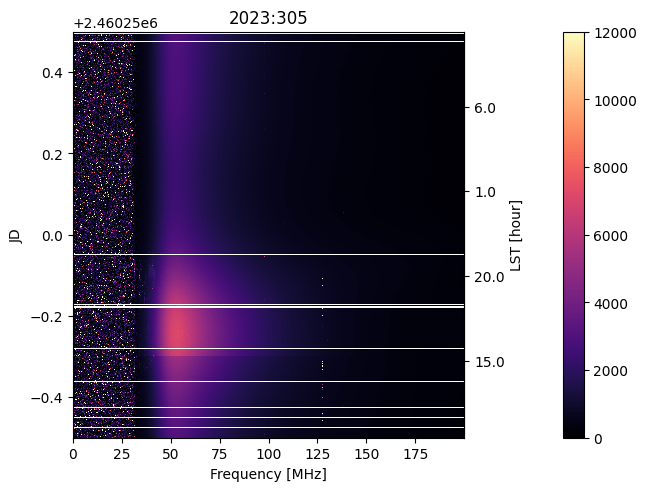

In [42]:
plots.plot_waterfall(data, vmin= 0, vmax=1.2e4);

In [44]:
# Exit early if there's no data left.
if np.sum(~data.complete_flags)==0:
    sys.exit(0)

In [45]:
# Save the flags
np.savez(cache / f"{obsname}.integration-flags.npz", **{name: data.flags[name].flags for name in data.flags})

### Average Over LSTs

In [46]:
lstbin_data = lst_bin(data, **lstbin_params)

/data4/vydula/edges/packages/edges-analysis/src/edges_analysis/averaging/averaging.py:573: RuntimeWarning: invalid value encountered in multiply
  sm = np.nansum(data * weights, axis=axis)
/home/vydula/src/anaconda/envs/prefect-edges/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/data4/vydula/edges/packages/pygsdata/src/pygsdata/register.py:25: UserWarning: Auxiliary measurements cannot being binned!
  newdata = self.func(data, *args, **kw)


In [47]:
data = select_freqs(lstbin_data, freq_range=[first_freqcut_min*un.MHz, first_freqcut_max*un.MHz])
pre_rfi_data = deepcopy(data)

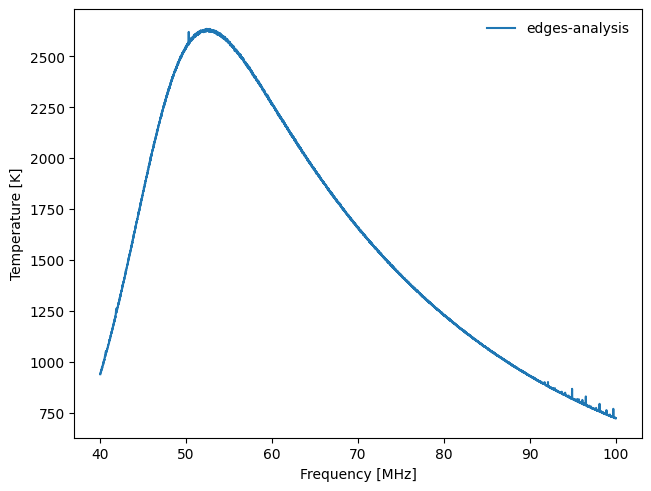

In [48]:
utils.plot_single_spectrum(data)

## Single-LST-Bin Workflow

### RFI Excision

In [49]:
pre_rfi_file = (cache/ obsname).with_suffix('.pre-rfi.gsh5')
try:
    pre_rfi_data.write_gsh5(pre_rfi_file);
except NameError:
    pre_rfi_data = GSData.from_file(pre_rfi_file)
    

In [39]:
#alan_rfi_flags = ~np.genfromtxt(alan_output_dir/"rfi_flags.txt").astype(bool)

In [51]:

data = filters.rfi_model_nonlinear_window_filter(
    pre_rfi_data,
    max_iter=10,
    model = mdl.Fourier(n_terms=37, period=1.5, transform=mdl.ZerotooneTransform(
        range=(
            data.freqs.min().to_value("MHz"), 
            data.freqs.max().to_value("MHz"),
        )
    )),
    fit_kwargs = {"method": 'alan-qrd'},
    #window_frac = 16,
    #min_window_size = 10,
    threshold = 4.5,
    reflag_thresh = 1.0,
    # watershed = {
    #     1.0: 4,
    #     10.0: 8,
    #     100.0: 16
    #}
)

In [52]:
print(f"{data.complete_flags.sum()}/{data.nfreqs} channels flagged during xrfi")

34158/9831 channels flagged during xrfi


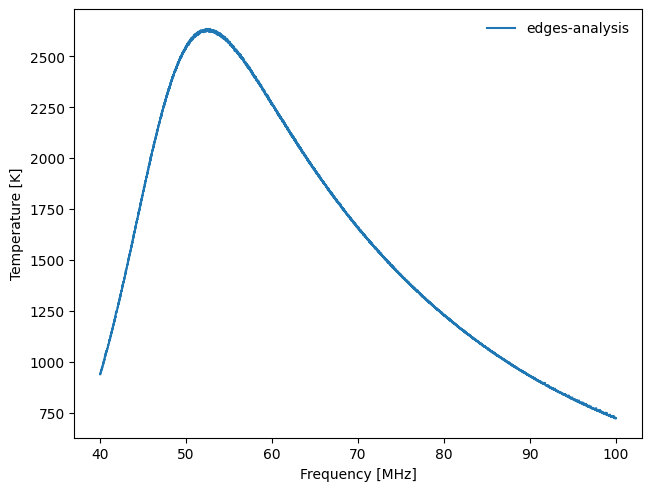

In [53]:
utils.plot_single_spectrum(data)

### Smooth Over Frequency

In [54]:
pre_smooth_data = deepcopy(data)

In [55]:
data = gauss_smooth(data, **gauss_smooth_params)

/data4/vydula/edges/packages/edges-analysis/src/edges_analysis/averaging/freqbin.py:141: RuntimeWarning: invalid value encountered in divide
  nsamples[nsamples / maxn <= size * flag_threshold] = 0


In [56]:
# After smoothing, any flags over the frequency axis are removed, but nsamples is maintained correctly.
ourflags = data.nsamples[0,0,0] == 0

In [57]:
pre_cal_data = deepcopy(data)

In [59]:
#alan_avg, n = read_spec_txt(alan_output_dir/"spegva.txt")

In [60]:
#assert np.sum(~ourflags ^ (alan_avg['weight']>0))==0

In [61]:
#utils.plot_single_spectrum(pre_cal_data, alan_avg['spectra'])

In [62]:
cache / f"{obsname}.averaged.gsh5"

PosixPath('cache/2023_305.averaged.gsh5')

In [63]:
pre_cal_data.write_gsh5(cache/f"{obsname}.averaged.gsh5");